<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week15_Latihan_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [9]:
from google.colab import files
uploaded = files.upload()

Saving dataKelas.csv to dataKelas (1).csv


In [10]:
df = pd.read_csv('dataKelas.csv')
print(df.head())

            Timestamp                            Nama Tempat Lahir  \
0  2/10/2026 18:47:53           Pratama Angga Saputra       Malang   
1  2/10/2026 18:55:03  Muchammad Nabil Haykal Widarto  Kota Malang   
2  2/10/2026 18:55:51              Moh. Rafael Abrari     Lamongan   
3  2/10/2026 19:49:44          Muhamad Miftahul Akmal      Cilegon   
4  2/10/2026 19:54:36     Narendra Daniswara Alamsyah   Bojonegoro   

  Tanggal Lahir Jenis Kelamin  Tinggi Badan (cm)  Berat Badan (kg)  \
0     7/10/2005     Laki-Laki                165              52.5   
1     3/22/2004     Laki-Laki                175             123.0   
2    11/27/2006     Laki-Laki                173              55.0   
3      3/5/2005     Laki-Laki                168              70.0   
4     2/16/2006     Laki-Laki                166              64.0   

     Kota Asal                Alamat Domisili Saat Ini Jenis Kendaraan Utama  \
0       Malang      Jl. Mergan lori 2b no 51 RT 5 RW 6                 Motor  

In [11]:
df = df.drop(
    columns=[
        "Timestamp",
        "Nama",
        "Tempat Lahir",
        "Tanggal Lahir"
    ]
)


df.head()

,Jenis Kelamin,Tinggi Badan (cm),Berat Badan (kg),Kota Asal,Alamat Domisili Saat Ini,Jenis Kendaraan Utama,Pengeluaran BBM/Transport per Bulan (Rp),IPK Semester Kemarin,Hobi,Alat Utama Mencatat Saat Kuliah,MBTI (kepribadian),Waktu Produktif/Fokus,Rata - Rata Screen Time HP per Hari (jam),Aplikasi Yang Paling Sering Dibuka di HP,Metode Pembayaran Favorit,Usia (tahun),Jumlah Aplikasi di Hp,Jumlah Device yang Dimiliki,Pekerjaan Impian
0,Laki-Laki,165,52.5,Malang,Jl. Mergan lori 2b no 51 RT 5 RW 6,Motor,100000,3.80,Menonton Anime dan Baca Manhwa,Laptop,INFP,Malam,5.5,Webtoon,Cash,20,68,2,Front End Dev
1,Laki-Laki,175,123.0,Kota Malang,Perumahan Bukit Cemara Tidar C5 No. 29,Motor,200000,3.60,"Voli, Game, Sepakbola, Nonton Film, Baca Buku",Laptop,ISTJ,Malam,8 - 10,Facebook,Cash,21,50,2,Back End Dev
2,Laki-Laki,173,55.0,Lamongan,jl. kenanga indah,Motor,100,3.65,Mancing,Ingatan,Mengaji,Malam,5,Instagram,QRIS,19,30,2,Data Analyst
3,Laki-Laki,168,70.0,Cilegon,Jalan pisang kipas dalam,Motor,150000,3.73,Tiduran dan bersantai santai,Laptop,INFP,Malam,10,Whatsapp,Cash,20,10,2,Front End Dev
4,Laki-Laki,166,64.0,Bojonegoro,"Jl. Ikan Mujair Raya, No. 04",Motor,60000,3.58,Bersepeda,Buku,ISFP,Pagi,3.5,Twitter,QRIS,20,31,2,Data Analyst


In [12]:
encoder = LabelEncoder()


for kolom in df.columns:

    if df[kolom].dtype == "object":

        df[kolom] = encoder.fit_transform(
            df[kolom]
        )


df.head()

,Jenis Kelamin,Tinggi Badan (cm),Berat Badan (kg),Kota Asal,Alamat Domisili Saat Ini,Jenis Kendaraan Utama,Pengeluaran BBM/Transport per Bulan (Rp),IPK Semester Kemarin,Hobi,Alat Utama Mencatat Saat Kuliah,MBTI (kepribadian),Waktu Produktif/Fokus,Rata - Rata Screen Time HP per Hari (jam),Aplikasi Yang Paling Sering Dibuka di HP,Metode Pembayaran Favorit,Usia (tahun),Jumlah Aplikasi di Hp,Jumlah Device yang Dimiliki,Pekerjaan Impian
0,0,165,52.5,8,9,1,100000,3.80,8,3,5,0,5,5,0,20,68,2,2
1,0,175,123.0,4,12,1,200000,3.60,14,3,8,0,10,0,0,21,50,2,0
2,0,173,55.0,5,15,1,100,3.65,3,2,9,0,2,1,1,19,30,2,1
3,0,168,70.0,2,4,1,150000,3.73,12,3,5,0,0,7,0,20,10,2,2
4,0,166,64.0,1,8,1,60000,3.58,2,0,7,1,1,4,1,20,31,2,1


In [13]:
X = df.drop(
    "Pekerjaan Impian",
    axis=1
)


y = df["Pekerjaan Impian"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Jumlah data training :", X_train.shape)

print("Jumlah data testing :", X_test.shape)

Jumlah data training : (13, 18)
Jumlah data testing : (4, 18)


In [17]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

In [18]:
hasil_knn = []

for k in range(1,11):

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    # Training
    knn.fit(
        X_train_scaled,
        y_train
    )

    # Testing
    prediksi = knn.predict(
        X_test_scaled
    )

    # Accuracy
    akurasi = accuracy_score(
        y_test,
        prediksi
    )

    hasil_knn.append(
        [
            k,
            akurasi
        ]
    )

In [19]:
hasil = pd.DataFrame(
    hasil_knn,
    columns=[
        "Nilai K",
        "Accuracy"
    ]
)


hasil

,Nilai K,Accuracy
0,1,0.25
1,2,0.25
2,3,0.25
3,4,0.25
4,5,0.25
5,6,0.50
6,7,0.25
7,8,0.00
8,9,0.25
9,10,0.25


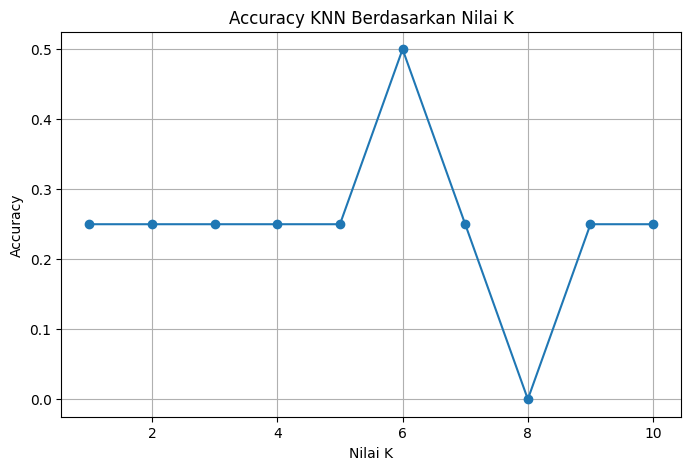

In [20]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    hasil["Nilai K"],
    hasil["Accuracy"],
    marker="o"
)

plt.xlabel(
    "Nilai K"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Accuracy KNN Berdasarkan Nilai K"
)

plt.grid()

plt.show()

In [21]:
k_terbaik = hasil.loc[
    hasil["Accuracy"].idxmax()
]


k_terbaik

,5
Nilai K,6.0
Accuracy,0.5


In [22]:
knn_minkowski = KNeighborsClassifier(
    n_neighbors=int(k_terbaik["Nilai K"]),
    metric="minkowski"
)

knn_minkowski.fit(
    X_train_scaled,
    y_train
)

pred_minkowski = knn_minkowski.predict(
    X_test_scaled
)

accuracy_minkowski = accuracy_score(
    y_test,
    pred_minkowski
)

print(
    "Accuracy Minkowski :",
    accuracy_minkowski
)

Accuracy Minkowski : 0.5


In [23]:
knn_euclidean = KNeighborsClassifier(
    n_neighbors=int(k_terbaik["Nilai K"]),
    metric="euclidean"
)

knn_euclidean.fit(
    X_train_scaled,
    y_train
)

pred_euclidean = knn_euclidean.predict(
    X_test_scaled
)

accuracy_euclidean = accuracy_score(
    y_test,
    pred_euclidean
)

print(
    "Accuracy Euclidean :",
    accuracy_euclidean
)

Accuracy Euclidean : 0.5


In [24]:
hasil_distance = pd.DataFrame(
    {
        "Metode Distance":
        [
            "Minkowski",
            "Euclidean"
        ],

        "Accuracy":
        [
            accuracy_minkowski,
            accuracy_euclidean
        ]
    }
)
hasil_distance

,Metode Distance,Accuracy
0,Minkowski,0.5
1,Euclidean,0.5


In [ ]:
print(
    classification_report(
        y_test,
        pred_minkowski
    )
)

In [25]:
print(
    classification_report(
        y_test,
        pred_minkowski
    )
)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.50      1.00      0.67         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
